Read MRTM1 bp output and compare across subjects per region

In [2]:
import glob
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
bp_ex = pd.read_csv('/export/scratch1/PETPAL/12Nov24/sub-PIB09060_ses-VYr12/sub-PIB09060_ses-VYr12_bp-logan.tsv',sep='\t')['bp_logan']

In [4]:
bp_ex

0      5.775906e-01
1      2.531561e-01
2      5.924473e-01
3      3.634611e-01
4      3.172560e-01
           ...     
112    3.679763e-01
113   -2.220446e-16
114    3.822223e-01
115    1.334552e-01
116    4.354818e-01
Name: bp_logan, Length: 117, dtype: float64

In [5]:
tacs_files = glob.glob('/export/scratch1/PETPAL/12Nov24/sub-PIB09060_ses-VYr12/tacs/*')
bn = os.path.basename(tacs_files[10])

In [6]:
region_names = [os.path.basename(tac_file)[4:-4] for tac_file in tacs_files]

In [7]:
region_names

['LeftThalamus',
 'ctxrhsuperiorfrontal',
 'RightThalamus',
 'ctxlhmedialorbitofrontal',
 'ctxlhinferiortemporal',
 'ctxlhrostralmiddlefrontal',
 'LeftPutamen',
 'ctxlhinferiorparietal',
 'ctxlhfrontalpole',
 'LeftCaudate',
 'CCMidAnterior',
 'LeftCBMWM',
 'Skull',
 'ctxrhcuneus',
 'ctxlhparacentral',
 'ctxlhcaudalanteriorcingulate',
 'ctxlhlateralorbitofrontal',
 'LeftAmygdala',
 'RightAccumbensarea',
 'ctxlhsuperiorparietal',
 'ctxrhcaudalanteriorcingulate',
 'ctxlhparsopercularis',
 'RightCBMWM',
 'CSF',
 'HeadExtraCerebral',
 'ctxrhparstriangularis',
 'LeftLateralVentricle',
 'Unknown',
 'ctxrhbankssts',
 'ctxlhpostcentral',
 'ctxlhparahippocampal',
 'LeftPallidum',
 'ctxrhprecentral',
 'ctxlhlateraloccipital',
 'ctxlhparstriangularis',
 'ctxlhprecuneus',
 'ctxlhrostralanteriorcingulate',
 'CCCentral',
 'ctxrhrostralanteriorcingulate',
 'ctxrhinferiorparietal',
 'ctxlhlingual',
 'ctxrhlateralorbitofrontal',
 'ctxlhisthmuscingulate',
 'ctxlhsuperiortemporal',
 'Leftvessel',
 'ctxrht

In [8]:
subs = pd.read_csv('/export/scratch1/PETPAL/codes/participants_06Nov24.tsv',sep='\s+')['participant_id']

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2918262/2095301141.py:1: SyntaxWarning: invalid escape sequence '\s'
  subs = pd.read_csv('/export/scratch1/PETPAL/codes/participants_06Nov24.tsv',sep='\s+')['participant_id']


In [9]:
def rename_subs(sub: str):
    """
    Handle converting subject ID to BIDS structure.

    VATDYS0XX -> sub-VATDYS0XX
    PIBXX-YYY_VYrZ -> sub-PIBXXYYY_ses-VYrZ

    returns:
        - subject part string
        - session part string
    """
    if 'VAT' in sub:
        return f'sub-{sub}'
    elif 'PIB' in sub:
        subname, sesname = sub.split('_')
        subname = subname.replace('-','')
        subname = f'sub-{subname}'
        sesname = f'ses-{sesname}'
        return f'{subname}_{sesname}'

In [ ]:
def rename_subs_rc(sub: str):
    """
    Handle converting subject ID to BIDS structure.

    VATDYS0XX -> sub-VATDYS0XX
    PIBXX-YYY_VYrZ -> sub-PIBXXYYY_ses-VYrZ

    returns:
        - subject part string
        - session part string
    """
    if 'VAT' in sub:
        return f'sub-{sub}'
    elif 'PIB' in sub:
        subname, sesname = sub.split('-')
        subname = subname.replace('-','')
        subname = f'sub-{subname}'
        sesname = f'ses-{sesname}'
        return f'{subname}_{sesname}'

In [10]:
def reverse_name_subs(sub: str):
    """
    Handle converting subject ID to BIDS structure.

    VATDYS0XX -> sub-VATDYS0XX
    PIBXX-YYY_VYrZ -> sub-PIBXXYYY_ses-VYrZ

    returns:
        - subject part string
        - session part string
    """
    if 'VAT' in sub:
        return f'sub-{sub}'
    elif 'PIB' in sub:
        subname, sesname = sub.split('_')
        subname = subname.replace('-','')
        subname = f'sub-{subname}'
        sesname = f'ses-{sesname}'
        return f'{subname}_{sesname}'

In [11]:
bps = pd.DataFrame(index=region_names)
for sub in subs:
    sub_real = rename_subs(sub)
    bp_file = pd.read_csv(f'/export/scratch1/PETPAL/12Nov24/{sub_real}/{sub_real}_bp-logan.tsv',sep='\t')['bp_logan']
    bps[sub_real] = bp_file

In [12]:
spb = bps.transpose()

In [13]:
spb['LeftPutamen']

sub-PIB10081_ses-VYr6    NaN
sub-PIB12154_ses-VYr7    NaN
sub-PIB09060_ses-VYr12   NaN
sub-PIB12142_ses-VYr6    NaN
sub-PIB07018_ses-VYr12   NaN
sub-PIB10077_ses-VYr6    NaN
sub-PIB11106_ses-VYr12   NaN
sub-PIB12120_ses-VYr7    NaN
sub-PIB19291_ses-VYr0    NaN
sub-PIB12149_ses-VYr10   NaN
sub-PIB19296_ses-VYr0    NaN
sub-PIB17280_ses-VYr0    NaN
sub-PIB12151_ses-VYr6    NaN
sub-VATNL017             NaN
sub-PIB20299_ses-VYr0    NaN
sub-VATNL016             NaN
sub-PIB10074_ses-VYr6    NaN
sub-VATNL042             NaN
sub-VATNL024             NaN
sub-PIB10078_ses-VYr12   NaN
sub-VATDYS003            NaN
sub-VATDYS004            NaN
sub-VATDYS005            NaN
sub-VATDYS006            NaN
sub-VATDYS007            NaN
sub-VATDYS009            NaN
sub-VATDYS010            NaN
sub-VATDYS011            NaN
sub-VATDYS012            NaN
sub-VATDYS013            NaN
sub-VATDYS014            NaN
sub-VATDYS016            NaN
sub-VATDYS017            NaN
sub-VATDYS018            NaN
sub-VATDYS019 

In [14]:
bps = pd.DataFrame(columns=['Participant','BP','Region','Group'])
Participant = []
BP = []
Region = []
Group = []
for i,sub in enumerate(subs):
    sub_real = rename_subs(sub)
    bp_file = pd.read_csv(f'/export/scratch1/PETPAL/12Nov24/{sub_real}/{sub_real}_bp-logan.tsv',sep='\t')['bp_logan']
    for j,region in enumerate(region_names):
        Participant += [sub_real]
        BP += [bp_file[j]]
        if 'VATDYS' in sub:
            group = 'CD'
        elif 'VATNL' or 'PIB' in sub:
            group = 'HC'
        Group += [group]
        Region += [region]
bps['Participant'] = Participant
bps['BP'] = BP
bps['Region'] = Region
bps['Group'] = Group

In [15]:
bps[:50]

,Participant,BP,Region,Group
0,sub-PIB10081_ses-VYr6,0.855419,LeftThalamus,HC
1,sub-PIB10081_ses-VYr6,0.269252,ctxrhsuperiorfrontal,HC
2,sub-PIB10081_ses-VYr6,0.767167,RightThalamus,HC
3,sub-PIB10081_ses-VYr6,0.408012,ctxlhmedialorbitofrontal,HC
4,sub-PIB10081_ses-VYr6,0.296428,ctxlhinferiortemporal,HC
5,sub-PIB10081_ses-VYr6,0.299560,ctxlhrostralmiddlefrontal,HC
6,sub-PIB10081_ses-VYr6,2.743953,LeftPutamen,HC
7,sub-PIB10081_ses-VYr6,0.330885,ctxlhinferiorparietal,HC
8,sub-PIB10081_ses-VYr6,0.005643,ctxlhfrontalpole,HC
9,sub-PIB10081_ses-VYr6,1.549303,LeftCaudate,HC


In [16]:
bps[bps['Region']=='RightCaudate']

,Participant,BP,Region,Group
94,sub-PIB10081_ses-VYr6,1.593690,RightCaudate,HC
211,sub-PIB12154_ses-VYr7,1.458841,RightCaudate,HC
328,sub-PIB09060_ses-VYr12,1.733102,RightCaudate,HC
445,sub-PIB12142_ses-VYr6,2.175165,RightCaudate,HC
562,sub-PIB07018_ses-VYr12,1.020121,RightCaudate,HC
679,sub-PIB10077_ses-VYr6,1.996954,RightCaudate,HC
796,sub-PIB11106_ses-VYr12,2.093262,RightCaudate,HC
913,sub-PIB12120_ses-VYr7,1.757004,RightCaudate,HC
1030,sub-PIB19291_ses-VYr0,1.672898,RightCaudate,HC
1147,sub-PIB12149_ses-VYr10,2.037498,RightCaudate,HC


In [17]:
bps['Participant']

0       sub-PIB10081_ses-VYr6
1       sub-PIB10081_ses-VYr6
2       sub-PIB10081_ses-VYr6
3       sub-PIB10081_ses-VYr6
4       sub-PIB10081_ses-VYr6
                ...          
4675            sub-VATDYS032
4676            sub-VATDYS032
4677            sub-VATDYS032
4678            sub-VATDYS032
4679            sub-VATDYS032
Name: Participant, Length: 4680, dtype: object

In [72]:
a = [bps[bps['Region']=='RightCaudate'][bps['Participant']=='sub-VATDYS024']['BP'],bps[bps['Region']=='LeftCaudate'][bps['Participant']=='sub-VATDYS024']['BP']]
print(a)
print(np.mean(a))

[4540    2.595041
Name: BP, dtype: float64, 4455    2.358054
Name: BP, dtype: float64]
2.4765477727959833


/tmp/ipykernel_2918262/3326911049.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  a = [bps[bps['Region']=='RightCaudate'][bps['Participant']=='sub-VATDYS024']['BP'],bps[bps['Region']=='LeftCaudate'][bps['Participant']=='sub-VATDYS024']['BP']]
/tmp/ipykernel_2918262/3326911049.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  a = [bps[bps['Region']=='RightCaudate'][bps['Participant']=='sub-VATDYS024']['BP'],bps[bps['Region']=='LeftCaudate'][bps['Participant']=='sub-VATDYS024']['BP']]


In [76]:
a[0].to_list()[0]

2.5950412134822085

In [107]:
def avg_rl(bps,regions):
    """
    Average the left and right BPs for a given region
    """
    bps_rl = pd.DataFrame(columns=['Participant','BP','Region','Group'])
    Participant = []
    BP = []
    Region = []
    Group = []
    subs = bps['Participant'].unique()
    print(subs)
    for sub in subs:
        for i,region in enumerate(regions):
            if 'Left' in region:
                region_right = f'Right{region[4:]}'
                bp_left = bps[bps['Region']==region][bps['Participant']==sub]['BP'].to_list()[0]
                bp_right = bps[bps['Region']==region_right][bps['Participant']==sub]['BP'].to_list()[0]
                region_avg = np.mean([bp_left,bp_right])
                region_short = region[4:]
            elif 'Right' in region:
                a = 1
            else:
                region_avg = bps[bps['Region']==region][bps['Participant']==sub]['BP'].to_list()[0]
                region_short = region
            Participant += [sub]
            BP += [region_avg]
            Region += [region_short]
            Group += [bps[bps['Region']==region][bps['Participant']==sub]['Group'].unique()[0]]
    bps_rl['Participant'] = Participant
    bps_rl['BP'] = BP
    bps_rl['Region'] = Region
    bps_rl['Group'] = Group
    return bps_rl

In [132]:
subcortical_regions = [
    'LeftThalamus',
    'RightThalamus',
    'LeftCaudate',
    'RightCaudate',
    'LeftPutamen',
    'RightPutamen',
    'LeftPallidum',
    'RightPallidum',
    'RightCBMCortex',
    'LeftCBMCortex',
    'LeftCBMWM',
    'RightCBMWM',
    'Pons',
    'Medulla',
    'Midbrain'
]

In [133]:
bps_rl = avg_rl(bps,subcortical_regions)

['sub-PIB10081_ses-VYr6' 'sub-PIB12154_ses-VYr7' 'sub-PIB09060_ses-VYr12'
 'sub-PIB12142_ses-VYr6' 'sub-PIB07018_ses-VYr12' 'sub-PIB10077_ses-VYr6'
 'sub-PIB11106_ses-VYr12' 'sub-PIB12120_ses-VYr7' 'sub-PIB19291_ses-VYr0'
 'sub-PIB12149_ses-VYr10' 'sub-PIB19296_ses-VYr0' 'sub-PIB17280_ses-VYr0'
 'sub-PIB12151_ses-VYr6' 'sub-VATNL017' 'sub-PIB20299_ses-VYr0'
 'sub-VATNL016' 'sub-PIB10074_ses-VYr6' 'sub-VATNL042' 'sub-VATNL024'
 'sub-PIB10078_ses-VYr12' 'sub-VATDYS003' 'sub-VATDYS004' 'sub-VATDYS005'
 'sub-VATDYS006' 'sub-VATDYS007' 'sub-VATDYS009' 'sub-VATDYS010'
 'sub-VATDYS011' 'sub-VATDYS012' 'sub-VATDYS013' 'sub-VATDYS014'
 'sub-VATDYS016' 'sub-VATDYS017' 'sub-VATDYS018' 'sub-VATDYS019'
 'sub-VATDYS020' 'sub-VATDYS022' 'sub-VATDYS023' 'sub-VATDYS024'
 'sub-VATDYS032']


/tmp/ipykernel_2918262/1051413888.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  bp_left = bps[bps['Region']==region][bps['Participant']==sub]['BP'].to_list()[0]
/tmp/ipykernel_2918262/1051413888.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  bp_right = bps[bps['Region']==region_right][bps['Participant']==sub]['BP'].to_list()[0]
/tmp/ipykernel_2918262/1051413888.py:28: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  Group += [bps[bps['Region']==region][bps['Participant']==sub]['Group'].unique()[0]]
/tmp/ipykernel_2918262/1051413888.py:28: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  Group += [bps[bps['Region']==region][bps['Participant']==sub]['Group'].unique()[0]]
/tmp/ipykernel_2918262/1051413888.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  bp_left = bps[bps['Region']==region][bps['Participant']==sub]['BP'].

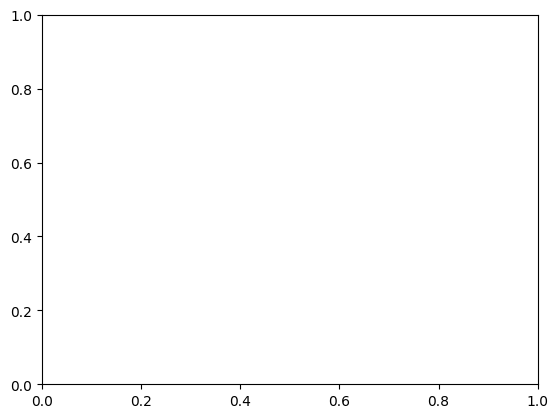

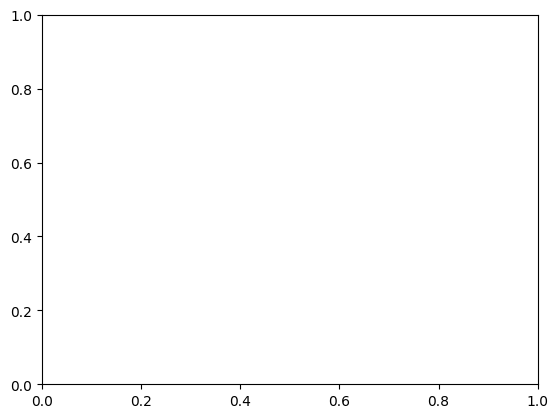

In [134]:
for region in ['RightCBMCortex','LeftCBMCortex']:
    try:
        plt.figure()
        temp_bp = bps_rl[bps_rl['Region']==region]
        sns.swarmplot(data=temp_bp,x='Region',y='BP',hue='Group',dodge=True)
        plt.ylim([0,1])
    except:
        print(f"oops couldn't plot region {region}")

<Axes: title={'center': 'Logan BP'}, xlabel='Region', ylabel='BP'>

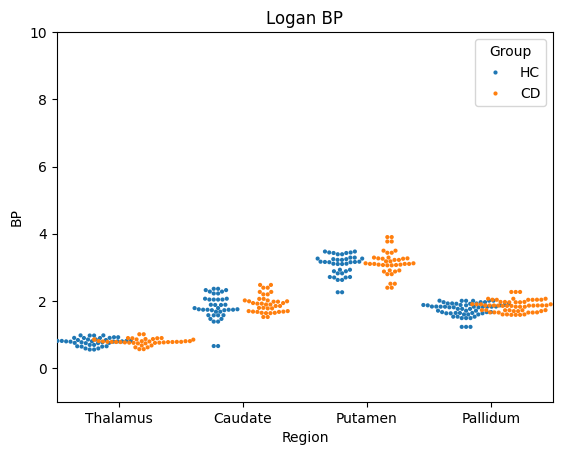

In [135]:
regions = ['Pallidum','Caudate','Putamen','Thalamus']
plt.figure()
temp_bp = bps_rl[bps_rl['Region'].isin(regions)]
plt.ylim([-1,10])
plt.title('Logan BP')
sns.swarmplot(data=temp_bp,x='Region',y='BP',hue='Group',dodge=True,size=3)

In [136]:
for region in regions:
    for group in ['HC','CD']:
        mean = np.mean(temp_bp[temp_bp['Region']==region][temp_bp['Group']==group]['BP'])
        std = np.std(temp_bp[temp_bp['Region']==region][temp_bp['Group']==group]['BP'])
        print(f'region {region}\t group {group}')
        print(f'mean {mean}')
        print(f'stdev {std}')

region Pallidum	 group HC
mean 1.7559736425936656
stdev 0.19143329832940195
region Pallidum	 group CD
mean 1.852321302189082
stdev 0.17089732175833153
region Caudate	 group HC
mean 1.8083102206433672
stdev 0.38187219322557053
region Caudate	 group CD
mean 1.9200650433530257
stdev 0.25407628750479233
region Putamen	 group HC
mean 3.0676136335053004
stdev 0.31092880074994356
region Putamen	 group CD
mean 3.141240030887245
stdev 0.350619050359211
region Thalamus	 group HC
mean 0.7868205604815242
stdev 0.11565697690137304
region Thalamus	 group CD
mean 0.7871760670961766
stdev 0.09530657235083247


/tmp/ipykernel_2918262/2081722991.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mean = np.mean(temp_bp[temp_bp['Region']==region][temp_bp['Group']==group]['BP'])
/tmp/ipykernel_2918262/2081722991.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  std = np.std(temp_bp[temp_bp['Region']==region][temp_bp['Group']==group]['BP'])
/tmp/ipykernel_2918262/2081722991.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mean = np.mean(temp_bp[temp_bp['Region']==region][temp_bp['Group']==group]['BP'])
/tmp/ipykernel_2918262/2081722991.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  std = np.std(temp_bp[temp_bp['Region']==region][temp_bp['Group']==group]['BP'])
/tmp/ipykernel_2918262/2081722991.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mean = np.mean(temp_bp[temp_bp['Region']==region][temp_bp['Group']==group]['BP'])
/tmp

In [137]:
r = 'Thalamus'
hc = bps_rl[bps_rl['Region']==r][bps_rl['Group']=='HC']['BP']
cd = bps_rl[bps_rl['Region']==r][bps_rl['Group']=='CD']['BP']

/tmp/ipykernel_2918262/4097406907.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  hc = bps_rl[bps_rl['Region']==r][bps_rl['Group']=='HC']['BP']
/tmp/ipykernel_2918262/4097406907.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cd = bps_rl[bps_rl['Region']==r][bps_rl['Group']=='CD']['BP']


In [138]:
covariates = pd.read_csv('/data/norris/data1/project/VATDYS/Analyses2024/vatdys_stats/pet/pandas_pats.mat',sep='\s+')

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2918262/3025309432.py:1: SyntaxWarning: invalid escape sequence '\s'
  covariates = pd.read_csv('/data/norris/data1/project/VATDYS/Analyses2024/vatdys_stats/pet/pandas_pats.mat',sep='\s+')


In [139]:
bps_rl['Region'].unique()

array(['Thalamus', 'Caudate', 'Putamen', 'Pallidum', 'CBMCortex', 'CBMWM',
       'Pons', 'Medulla', 'Midbrain'], dtype=object)

In [140]:
bps_rl[bps_rl['Region']=='Thalamus']['BP']

0      0.811293
1      0.811293
15     0.835618
16     0.835618
30     0.585019
         ...   
556    0.781871
570    0.674732
571    0.674732
585    0.774997
586    0.774997
Name: BP, Length: 80, dtype: float64

In [141]:
bps_rl

,Participant,BP,Region,Group
0,sub-PIB10081_ses-VYr6,0.811293,Thalamus,HC
1,sub-PIB10081_ses-VYr6,0.811293,Thalamus,HC
2,sub-PIB10081_ses-VYr6,1.571497,Caudate,HC
3,sub-PIB10081_ses-VYr6,1.571497,Caudate,HC
4,sub-PIB10081_ses-VYr6,2.711616,Putamen,HC
...,...,...,...,...
595,sub-VATDYS032,0.494810,CBMWM,CD
596,sub-VATDYS032,0.494810,CBMWM,CD
597,sub-VATDYS032,0.100399,Pons,CD
598,sub-VATDYS032,0.176747,Medulla,CD


In [142]:
covariates_spreadsheet = pd.read_excel('/data/norris/data1/data_archive/VATDYS/MatchedSubjects/VATDYSmatchedControlsCervical_20240801.xlsx')

In [143]:
bps_rl['Age'] = 0

In [144]:
bps_rl['Age']

0      0
1      0
2      0
3      0
4      0
      ..
595    0
596    0
597    0
598    0
599    0
Name: Age, Length: 600, dtype: int64

In [145]:
names = bps_rl.Participant.unique().tolist()
for i,pat in enumerate(covariates_spreadsheet['Control ID'].unique()):
    bps_rl.loc[bps_rl['Participant']==rename_subs(pat),'Age'] = covariates_spreadsheet['Control Age'][i]
for i,pat in enumerate(covariates_spreadsheet['Patient ID'].unique()):
    bps_rl.loc[bps_rl['Participant']==rename_subs(pat),'Age'] = covariates_spreadsheet['Patient Age'][i]

/tmp/ipykernel_2918262/4286348312.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '60.7994524298426' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  bps_rl.loc[bps_rl['Participant']==rename_subs(pat),'Age'] = covariates_spreadsheet['Control Age'][i]


In [146]:
bps_rl

,Participant,BP,Region,Group,Age
0,sub-PIB10081_ses-VYr6,0.811293,Thalamus,HC,60.799452
1,sub-PIB10081_ses-VYr6,0.811293,Thalamus,HC,60.799452
2,sub-PIB10081_ses-VYr6,1.571497,Caudate,HC,60.799452
3,sub-PIB10081_ses-VYr6,1.571497,Caudate,HC,60.799452
4,sub-PIB10081_ses-VYr6,2.711616,Putamen,HC,60.799452
...,...,...,...,...,...
595,sub-VATDYS032,0.494810,CBMWM,CD,65.000000
596,sub-VATDYS032,0.494810,CBMWM,CD,65.000000
597,sub-VATDYS032,0.100399,Pons,CD,65.000000
598,sub-VATDYS032,0.176747,Medulla,CD,65.000000


In [147]:
r1 = bps_rl['Age'].to_numpy()

In [148]:
r2 = bps_rl['BP'].to_numpy()

In [149]:
isinstance(r2[10],pd.Series)

False

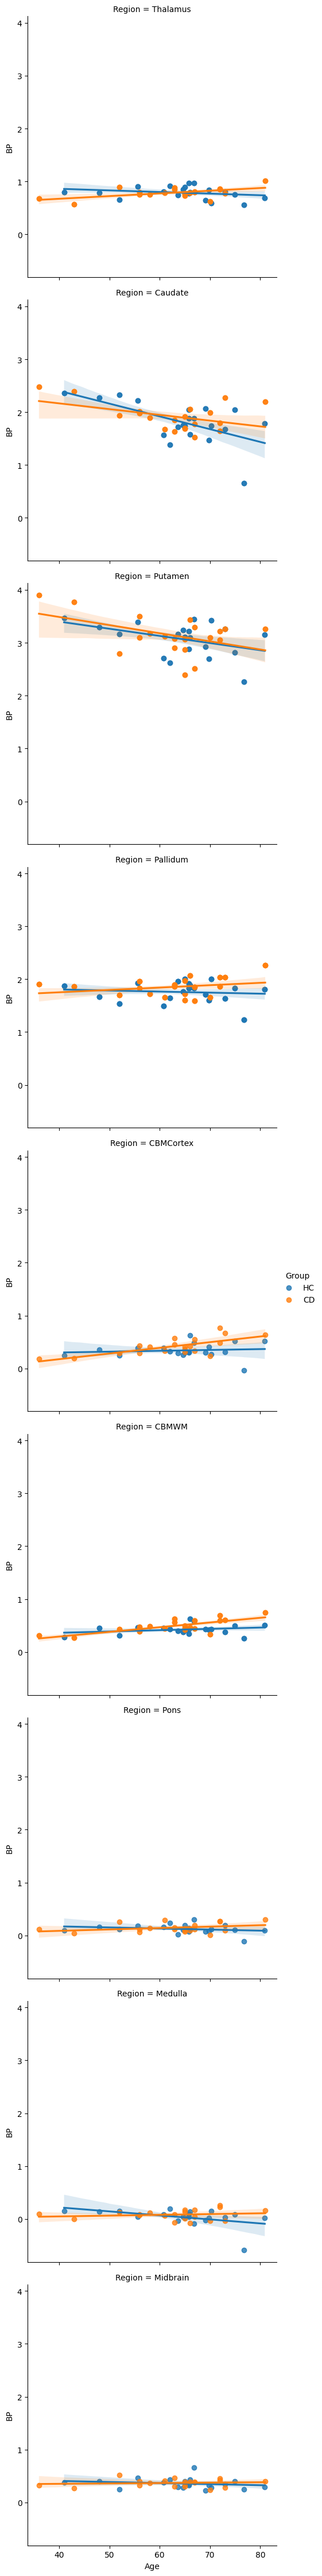

In [ ]:
sns.lmplot(data=bps_rl,x='Age',y='BP',hue='Group',row='Region',)

In [190]:
covariates_2 = pd.read_csv('/data/norris/data1/project/VATDYS/Covariates/VATDystonia-CovariatesSheet_DATA_LABELS_2024-12-20_1442.csv')

In [191]:
for participant in covariates_2['Participant Identification']:
    if 'VAT' in participant:
        covariates_2.loc[covariates_2['Participant Identification']==participant,'Participant Identification'] = rename_subs(participant)

In [194]:
covariates_2 = covariates_2.rename(columns={'Participant Identification': 'Participant','Enrollment Age:': 'Age','Time between last botulinum toxin injection and MRI study (weeks):': 'botox_time_mri', 'Time between last botulinum toxin injection and PET study (weeks):': 'botox_time','GDRS score:': 'GDRS'})

In [218]:
covariates_2 = covariates_2.set_index('Participant')

In [221]:
covariates_2

,Age,botox_time_mri,botox_time,Dystonia onset year:,GDRS
Participant,,,,,
PIB09-053,NaN,NaN,NaN,NaN,NaN
PIB09-055,NaN,NaN,NaN,NaN,NaN
PIB09-060,NaN,NaN,NaN,NaN,NaN
PIB10-077,NaN,NaN,NaN,NaN,NaN
PIB10-078,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
sub-VATNL022_CTR,NaN,NaN,NaN,NaN,NaN
sub-VATNL024_CTR,NaN,NaN,NaN,NaN,NaN
sub-VATNL028_CTR,NaN,NaN,NaN,NaN,NaN


In [234]:
bps_merged = bps_rl.join(covariates_2,on='Participant',rsuffix='_other',how='left')

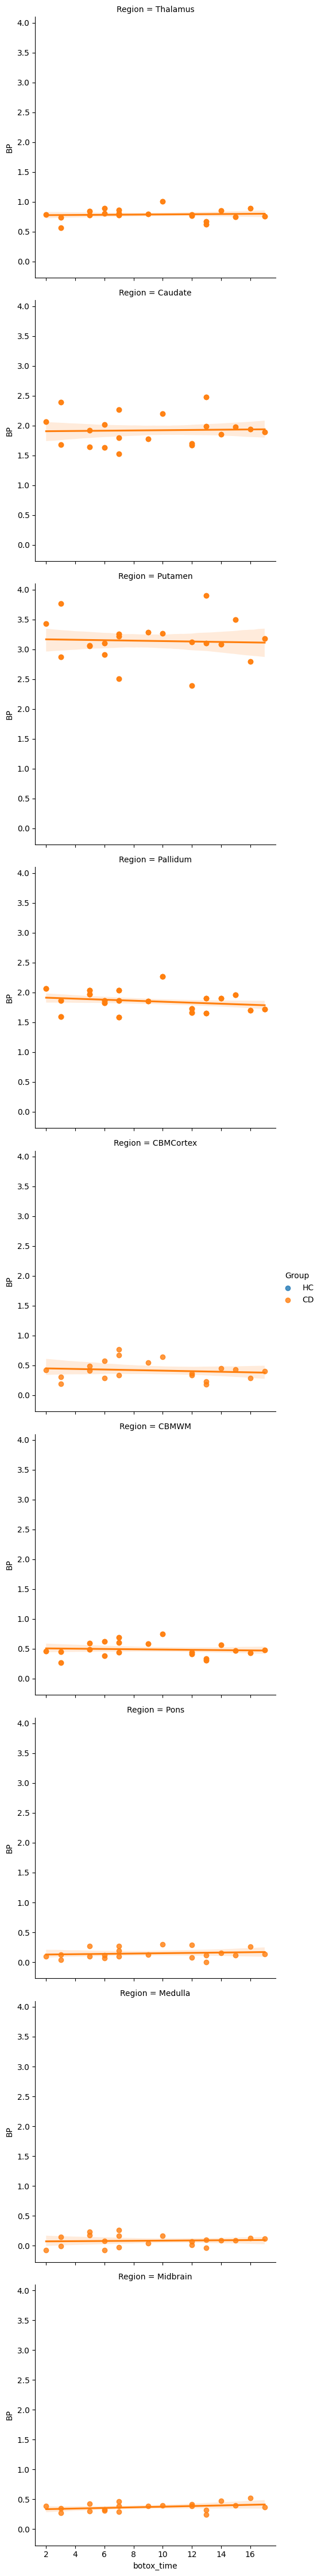

In [237]:
sns.lmplot(data=bps_merged,x='botox_time',y='BP',hue='Group',row='Region')